<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2024</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

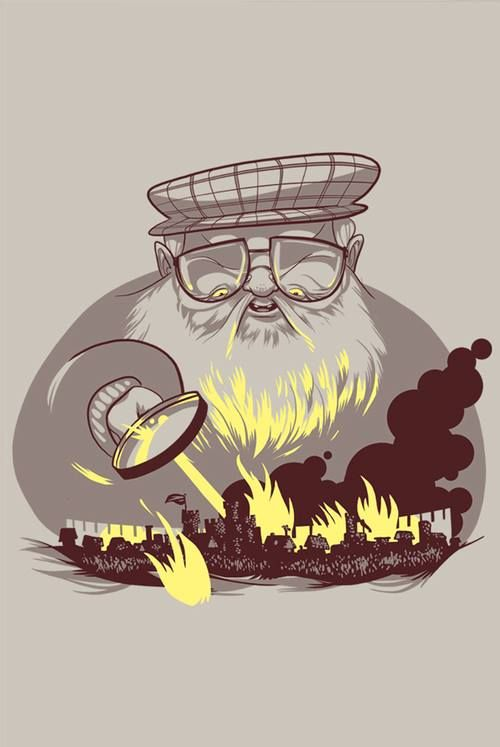

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Поехали!

Здесь нам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет...

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 65.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 54.3MB/s]


**Задание 1.1.** Импортируем библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Нужно загрузить датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, задаем значения колонки `S.No` наименованиями строк:

Загружаем data_train:

In [ ]:
data_train = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')

Загружаем data_test:

In [ ]:
data_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')

Посмотрим на них:

In [ ]:
data_train.head(10)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
6,Tommen Baratheon,NaN,1,NaN,NaN,Cersei Lannister,Robert Baratheon,Myrcella Baratheon,NaN,NaN,...,1.0,1.0,1.0,NaN,0,0,NaN,5,1.000000,1
7,Valarr Targaryen,Hand of the King,1,Valyrian,183.0,NaN,NaN,NaN,House Targaryen,Kiera of Tyrosh,...,NaN,NaN,NaN,1.0,1,1,26.0,0,0.431438,0
8,Viserys I Targaryen,NaN,1,NaN,NaN,Alyssa Targaryen,Baelon Targaryen,Rhaenyra Targaryen,NaN,NaN,...,1.0,1.0,1.0,NaN,0,0,NaN,5,0.678930,0
9,Wilbert,Ser,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.006689,0


25 колонок и Много Nan'ов

In [ ]:
data_test.head(10)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,NaN,0,NaN,156.0,NaN,NaN,NaN,House Blackwood,NaN,...,1,NaN,NaN,NaN,NaN,0,0,100.0,0,0.050167
1559,Melisandre,NaN,0,Asshai,NaN,NaN,NaN,NaN,R'hllor,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.745819
1560,Merrit,NaN,0,NaN,NaN,NaN,NaN,NaN,Brotherhood without banners,NaN,...,0,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033
1561,Meryn Trant,Ser,1,NaN,NaN,NaN,NaN,NaN,House Trant,NaN,...,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.220736
1562,Merrett Frey,NaN,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,1,NaN,NaN,NaN,1.0,1,0,38.0,0,0.434783
1563,Mohor,NaN,1,NaN,NaN,NaN,NaN,NaN,House Bracken,NaN,...,0,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033
1564,Missandei,NaN,0,Naathi,288.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,17.0,0,0.173913
1565,Moon Boy,NaN,1,NaN,NaN,NaN,NaN,NaN,House Baratheon of King's Landing,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923
1566,Monster,NaN,0,Free Folk,299.0,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,0,0,6.0,0,0.076923


Очень много Nan'ов

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируем, есть ли в колонках NaN значения. Если есть (а они есть), решим, как мы их будем обрабатывать. Их можно либо удалить, либо заполнить каким нибудь значением (например, медианой или модой).

Посмотрим на состав data_train.

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

Найдем количество NaN'ов в каждой колонке

In [ ]:
data_train.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


Визуализируем наши расчеты:

<BarContainer object of 25 artists>

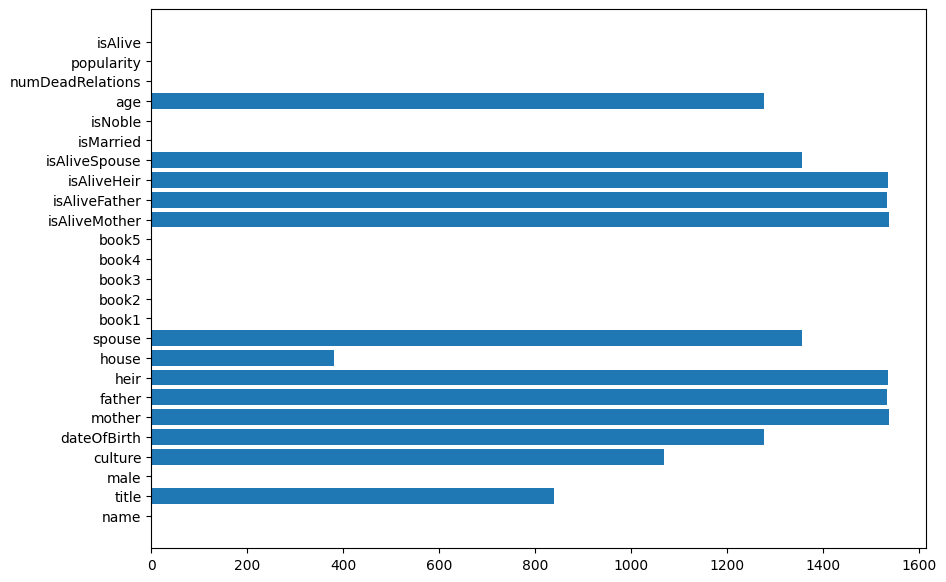

In [ ]:
data = data_train.isna().sum(axis=0)
plt.figure(figsize=(10,7))

plt.barh(data.index, data.values)



Посмотрим, как распределены NaN в колонках

<Axes: xlabel='S.No'>

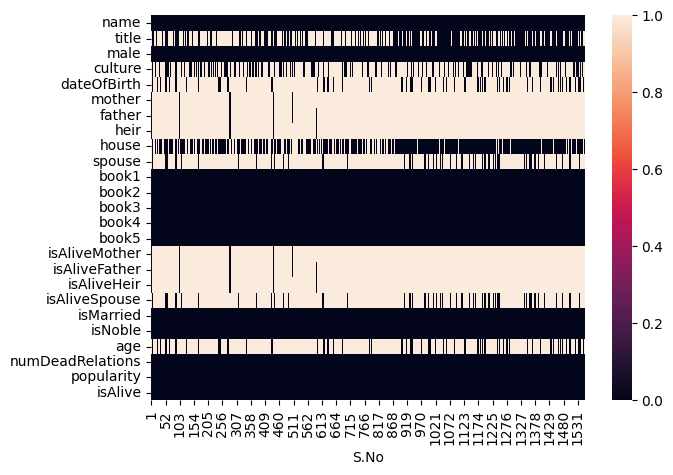

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(data_train.isna().transpose())

Титулы и дома можно попробовать вытащить из имен, информацию о родственниках убрать. Дата рождения и возрасть крайне интересны, нужно посмотреть поподробнее их связь с целевой переменной.

**Задание 1.4.** Создадим новые признаки:
* Признак isPopular. Возьмем в таблице признак popularity score, поставим пороговое значение, равное 0.5, и пусть персонажи, у которых popularity score меньше 0.5, будут считаться непопулярными, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Признак boolDeadRelations. Упростим признак numDeadRelations и поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростим признак culture, объединив схожие названия в один.


Для data_train:

In [ ]:
data_train['isPopular'] = data_train['popularity'].apply(lambda x: 1 if x>0.5  else 0)
data_train['boolDeadRelations'] = data_train['numDeadRelations'].apply(lambda x: 1 if x > 0 else 0)

Для data_test:

In [ ]:
data_test['isPopular'] = data_test['popularity'].apply(lambda x: 1 if x>0.5  else 0)
data_test['boolDeadRelations'] = data_test['numDeadRelations'].apply(lambda x: 1 if x > 0 else 0)

Воспользуемся данной в задании классификацией:

In [ ]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

Сделаем все буквы в названиях культур из датасета строчными и посмотрим на количество персонажей, принадлежащих различным культурам:

In [ ]:
data_train['culture'] = data_train['culture'].str.lower()
data_train['culture'].value_counts()

,count
culture,
northmen,103
ironborn,92
free folk,53
braavosi,39
valyrian,28
dornish,17
dothraki,17
ghiscari,17
reach,13


Имеет смысл объединить представителей редких культур объединить в единое множество. Но сначала реализуем объединение культур со схожими названиями и избавимся от NaN'ов:

In [ ]:
replace_dict = {v: k for k, values in cult.items() for v in values}
data_train['cult'] = data_train['culture'].replace(replace_dict)
data_train['cult'] = data_train['cult'].fillna('unknown_cult')

Проделаем аналогичное с data_test:

In [ ]:
data_test['culture'] = data_test['culture'].str.lower()
data_test['culture'].value_counts()

,count
culture,
northmen,30
ironborn,21
valyrian,15
dornishmen,11
free folk,10
westeros,9
rivermen,9
valemen,9
dornish,8


In [ ]:
data_test['cult'] = data_test['culture'].replace(replace_dict)
data_test['cult'] = data_test['cult'].fillna('unknown_cult')

Сравним количество культур до объединения и после.

Для data_train:

In [ ]:
data_train['cult'].nunique(), data_train['culture'].nunique()

(34, 46)

Для data_test:

In [ ]:
data_test['cult'].nunique(), data_test['culture'].nunique()

(37, 47)

Уменьшили на четверть. Неплохо.

Сделаем нечто похожее с домами и заодно попробуем достать информацию об отсутствующих домах, посмотрев на имена персонажей. Тут я пользуюсь своим знанием лора и функцией value_count 😁

In [ ]:
data_train['house'].value_counts()

,count
house,
House Frey,89
Night's Watch,88
House Stark,56
House Targaryen,40
House Lannister,36
...,...
House Celtigar,1
House of Ghazeen,1
House Byrch,1


In [ ]:
houses = ['Frey', 'Watch', 'Stark', 'Targaryen', 'Lannister', 'Arryn', 'Baratheon', 'Greyjoy', 'Tyrell', 'Osgrey', 'Martell'
          'Faith of the Seven', 'Hightower', 'Snow', 'Sand', 'Tully']

data_train['home'] = data_train['house']
data_test['home'] = data_test['house']

for h in houses:
  data_train.loc[(data_train['name'].str.contains(h)) | (data_train['house'].str.contains(h)), 'home'] = h
  data_test.loc[(data_test['name'].str.contains(h)) | (data_test['house'].str.contains(h)), 'home'] = h
data_train['home'] = data_train['home'].fillna('unknown_home')
data_test['home'] = data_test['home'].fillna('unknown_home')

Аналогично для титулов:

In [ ]:
data_train['title'].value_counts()

,count
title,
Ser,306
Maester,29
Archmaester,21
Lord,19
Septon,16
...,...
Sweetport Sound,1
Lord of Greyshield,1
Felwood,1


In [ ]:
titles = ['Ser', 'Maester', 'Master', 'Archmaester', 'Lord', 'Lady', 'Septon', 'Septa',
       'Prince', 'Princess', 'King', 'Queen', 'Khal', 'Bloodrider']

data_train['tit'] = data_train['title']
data_test['tit'] = data_test['title']
for t in titles:
  data_train.loc[(data_train['name'].str.contains(t)) | (data_train['title'].str.contains(t)), 'tit'] = t
  data_test.loc[(data_test['name'].str.contains(t)) | (data_test['title'].str.contains(t)), 'tit'] = t
data_train['tit'] = data_train['tit'].fillna('unknown_tit')
data_test['tit'] = data_test['tit'].fillna('unknown_tit')

Ну и самое интересное: возраст. Создадим новую колонку, равную сумме даты рождения и возраста. В теории, получившееся значение должно получиться одинаковым у всех живых.

In [ ]:
import statistics

data_train['years'] = data_train['dateOfBirth'] + data_train['age']
data_train['years'] = data_train['years'].fillna(0)
data_test['years'] = data_test['dateOfBirth'] + data_test['age']
data_test['years'] = data_test['years'].fillna(0)

**Задание 1.5.** Проанализируем, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалим ненужные столбцы на свой вкус.

Снова смотрим на data_train

In [ ]:
data_train.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,age,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,NaN,11,0.605351,0,1,1,unknown_cult,Targaryen,unknown_tit,0.0
2,Walder Frey,Lord of the Crossing,1,rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,97.0,1,0.896321,1,1,1,rivermen,Frey,Lord,305.0
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,0,0.267559,1,0,0,unknown_cult,House Swyft,Ser,0.0
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,23.0,0,0.183946,0,0,0,unknown_cult,Arryn,Queen,105.0
5,Sylva Santagar,Greenstone,0,dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,29.0,0,0.043478,1,0,0,Dornish,House Santagar,Greenstone,305.0


И на data_test:

In [ ]:
data_test.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isNoble,age,numDeadRelations,popularity,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,NaN,0,NaN,156.0,NaN,NaN,NaN,House Blackwood,NaN,...,0,100.0,0,0.050167,0,0,unknown_cult,House Blackwood,unknown_tit,256.0
1559,Melisandre,NaN,0,asshai,NaN,NaN,NaN,NaN,R'hllor,NaN,...,0,NaN,0,0.745819,1,0,Asshai,R'hllor,unknown_tit,0.0
1560,Merrit,NaN,0,NaN,NaN,NaN,NaN,NaN,Brotherhood without banners,NaN,...,0,NaN,0,0.010033,0,0,unknown_cult,Brotherhood without banners,unknown_tit,0.0
1561,Meryn Trant,Ser,1,NaN,NaN,NaN,NaN,NaN,House Trant,NaN,...,1,NaN,0,0.220736,0,0,unknown_cult,House Trant,Ser,0.0
1562,Merrett Frey,NaN,1,riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,0,38.0,0,0.434783,0,0,riverlands,Frey,unknown_tit,300.0


Сравним количество NaN'ов в теперь уже дублирующихся колонках, убедимся, что ничего не пропустили при заполнении. Как и раньше, проделаем это для data_train:

In [ ]:
columns = ['title', 'tit', 'house', 'home', 'culture', 'cult', 'age', 'years']
for c in columns:
  na_percentage = round((data_train[c].isna().sum() / len(data_train[c])) * 100, 3)
  print(f'{na_percentage} % пропущенных данных у признака', c)


53.95 % пропущенных данных у признака title
0.0 % пропущенных данных у признака tit
24.47 % пропущенных данных у признака house
0.0 % пропущенных данных у признака home
68.658 % пропущенных данных у признака culture
0.0 % пропущенных данных у признака cult
82.081 % пропущенных данных у признака age
0.0 % пропущенных данных у признака years


И для data_test:

In [ ]:
columns = ['title', 'tit', 'house', 'home', 'culture', 'cult', 'age', 'years']
for c in columns:
  na_percentage = round((data_test[c].isna().sum() / len(data_test[c])) * 100, 3)
  print(f'{na_percentage} % пропущенных данных у признака', c)


43.188 % пропущенных данных у признака title
0.0 % пропущенных данных у признака tit
11.825 % пропущенных данных у признака house
0.0 % пропущенных данных у признака home
51.414 % пропущенных данных у признака culture
0.0 % пропущенных данных у признака cult
60.411 % пропущенных данных у признака age
0.0 % пропущенных данных у признака years


Теперь можно убрать изначальные колонки:

In [ ]:
data_train.drop(columns=['culture', 'popularity', 'numDeadRelations', 'house', 'title', 'dateOfBirth', 'age'], inplace = True)
data_train.head()

,name,male,mother,father,heir,spouse,book1,book2,book3,book4,...,isAliveSpouse,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,1,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,0,0,0,0,...,NaN,0,0,0,1,1,unknown_cult,Targaryen,unknown_tit,0.0
2,Walder Frey,1,NaN,NaN,NaN,Perra Royce,1,1,1,1,...,1.0,1,1,1,1,1,rivermen,Frey,Lord,305.0
3,Addison Hill,1,NaN,NaN,NaN,NaN,0,0,0,1,...,NaN,0,1,1,0,0,unknown_cult,House Swyft,Ser,0.0
4,Aemma Arryn,0,NaN,NaN,NaN,Viserys I Targaryen,0,0,0,0,...,0.0,1,1,0,0,0,unknown_cult,Arryn,Queen,105.0
5,Sylva Santagar,0,NaN,NaN,NaN,Eldon Estermont,0,0,0,1,...,1.0,1,1,1,0,0,Dornish,House Santagar,Greenstone,305.0


In [ ]:
data_test.drop(columns=['culture', 'popularity', 'numDeadRelations', 'house', 'title', 'dateOfBirth', 'age'], inplace = True)
data_test.head()

,name,male,mother,father,heir,spouse,book1,book2,book3,book4,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,0,NaN,NaN,NaN,NaN,0,0,0,0,...,NaN,NaN,0,0,0,0,unknown_cult,House Blackwood,unknown_tit,256.0
1559,Melisandre,0,NaN,NaN,NaN,NaN,0,1,1,1,...,NaN,NaN,0,0,1,0,Asshai,R'hllor,unknown_tit,0.0
1560,Merrit,0,NaN,NaN,NaN,NaN,0,0,1,1,...,NaN,NaN,0,0,0,0,unknown_cult,Brotherhood without banners,unknown_tit,0.0
1561,Meryn Trant,1,NaN,NaN,NaN,NaN,1,1,1,1,...,NaN,NaN,0,1,0,0,unknown_cult,House Trant,Ser,0.0
1562,Merrett Frey,1,NaN,NaN,NaN,Mariya Darry,1,1,1,1,...,NaN,1.0,1,0,0,0,riverlands,Frey,unknown_tit,300.0


Посмотрим еще раз на имеющиеся признаки:

<Axes: xlabel='S.No'>

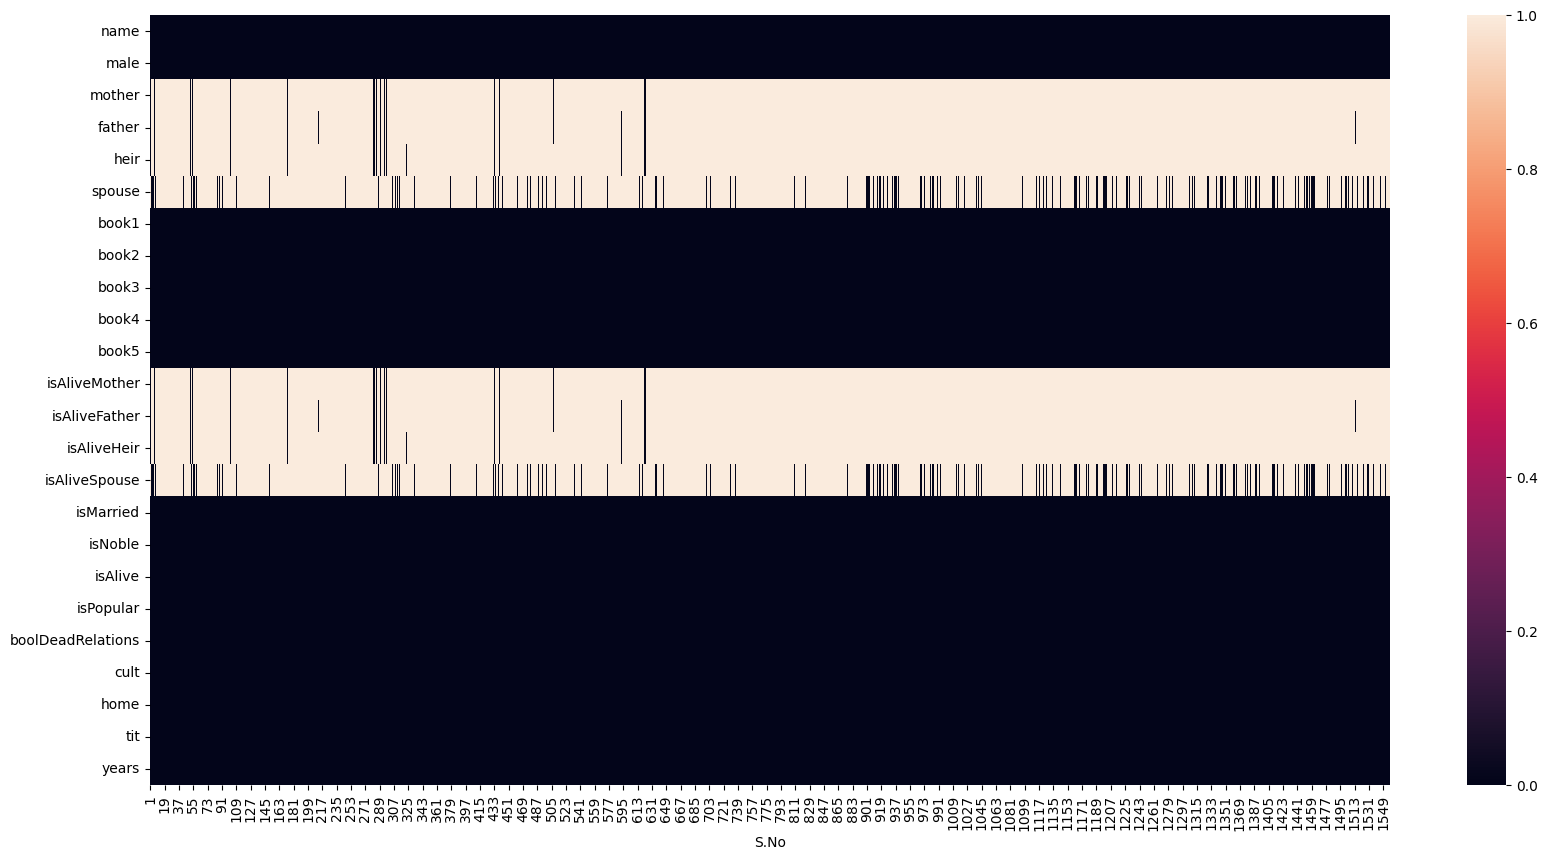

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(data_train.isna().transpose())

И уберем колонки, состоящие из NaN

In [ ]:
data_train.drop(columns=['name','mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse' ], inplace = True)
data_train.head()

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,1,1,unknown_cult,Targaryen,unknown_tit,0.0
2,1,1,1,1,1,1,1,1,1,1,1,rivermen,Frey,Lord,305.0
3,1,0,0,0,1,0,0,1,1,0,0,unknown_cult,House Swyft,Ser,0.0
4,0,0,0,0,0,0,1,1,0,0,0,unknown_cult,Arryn,Queen,105.0
5,0,0,0,0,1,0,1,1,1,0,0,Dornish,House Santagar,Greenstone,305.0


In [ ]:
data_test.drop(columns=['name','mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse' ], inplace = True)
data_test.head()

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0,0,unknown_cult,House Blackwood,unknown_tit,256.0
1559,0,0,1,1,1,1,0,0,1,0,Asshai,R'hllor,unknown_tit,0.0
1560,0,0,0,1,1,0,0,0,0,0,unknown_cult,Brotherhood without banners,unknown_tit,0.0
1561,1,1,1,1,1,1,0,1,0,0,unknown_cult,House Trant,Ser,0.0
1562,1,1,1,1,1,1,1,0,0,0,riverlands,Frey,unknown_tit,300.0


И еще раз посмотрим на результат:

<Axes: xlabel='S.No'>

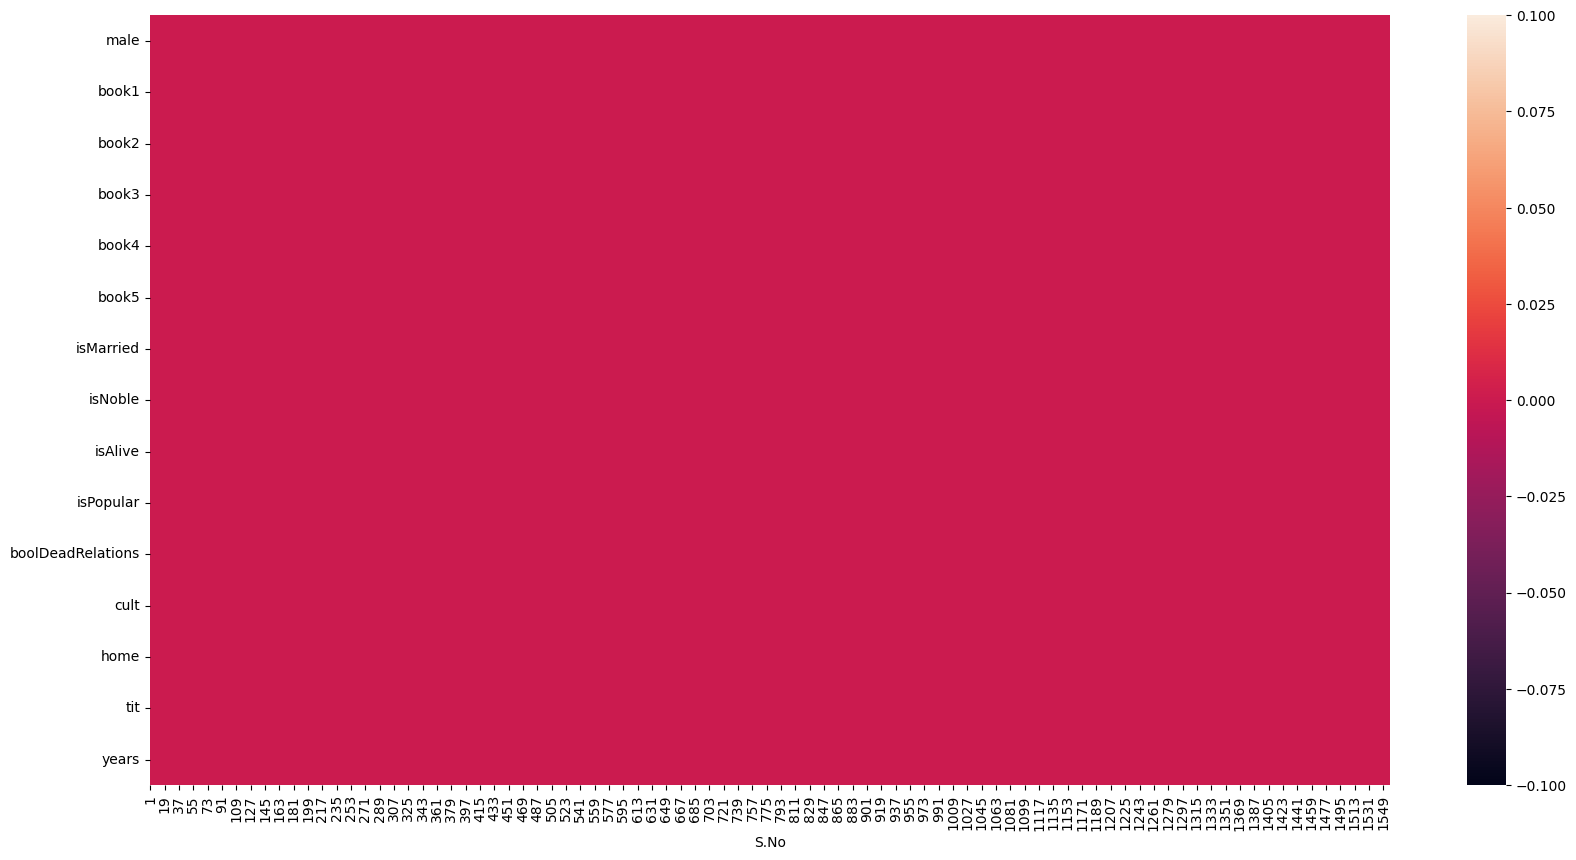

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(data_train.isna().transpose())

Вот теперь красота 😍

Но сделаем еще кое-что: объединим малочисленные дома, колонки и титулы в новое для каждого из трех признаков подмножество. Малочисленные - это меньше 5 представителей.

In [ ]:
tit_counts = data_train['tit'].value_counts()
data_train['tit'] = data_train['tit'].apply(lambda x: x if tit_counts[x] >= 5 else 'other_tit')
cult_counts = data_train['cult'].value_counts()
data_train['cult'] = data_train['cult'].apply(lambda x: x if cult_counts[x] >= 5 else 'other_cult')
home_counts = data_train['home'].value_counts()
data_train['home'] = data_train['home'].apply(lambda x: x if home_counts[x] >= 5 else 'other_home')

In [ ]:
tit_counts = data_test['tit'].value_counts()
data_test['tit'] = data_test['tit'].apply(lambda x: x if tit_counts[x] >= 5 else 'other_tit')
cult_counts = data_test['cult'].value_counts()
data_test['cult'] = data_test['cult'].apply(lambda x: x if cult_counts[x] >= 5 else 'other_cult')
home_counts = data_test['home'].value_counts()
data_test['home'] = data_test['home'].apply(lambda x: x if home_counts[x] >= 5 else 'other_home')

Ура! Насчет string-признаков мой внутренний перфекционист спокоен.
Теперь посмотрим на колонку с годами и сравненим ее значения с целевой переменной:

In [ ]:
pd.crosstab(data_train['years'], data_train['isAlive'])

isAlive,0,1
years,,
0.0,255,1023
10.0,1,0
43.0,1,0
47.0,1,0
82.0,1,0
105.0,2,0
114.0,1,0
120.0,2,0
129.0,3,0


Хммм)))

Какая интересная закономерность. Сделаем ее еще более очевидной: всех бывших обладателей NaN отметим нулем. Тех, у кого years равно 305, отметим единицей. А остальных пометим -1.

Для data_train:

In [ ]:
data_train['years'] = data_train['years'].apply(lambda x: x if (x == 0) | (x == 305) else -1)
data_train['years'] = data_train['years'].apply(lambda x: 1 if (x == 305) else x)

Ну и особенно для data_test :)

In [ ]:
data_test['years'] = data_test['years'].apply(lambda x: x if (x == 0) | (x == 305) else -1)
data_test['years'] = data_test['years'].apply(lambda x: 1 if (x == 305) else x)

Смотрим на результат:

In [ ]:
data_train.head(5)

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,cult,home,tit,years
S.No,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,1,1,unknown_cult,Targaryen,unknown_tit,0.0
2,1,1,1,1,1,1,1,1,1,1,1,rivermen,Frey,Lord,1.0
3,1,0,0,0,1,0,0,1,1,0,0,unknown_cult,House Swyft,Ser,0.0
4,0,0,0,0,0,0,1,1,0,0,0,unknown_cult,Arryn,Queen,-1.0
5,0,0,0,0,1,0,1,1,1,0,0,Dornish,other_home,other_tit,1.0


И заметим, что мы плавно перешли к анализу целевой переменной, а именно - к заданию 1.6.

**Задание 1.6.** Анализируем целевую переменную. Она является категориальной. Так как мы говорим о задаче классификации, проанализируем, является ли датасет сбалансированным по классам или нет.

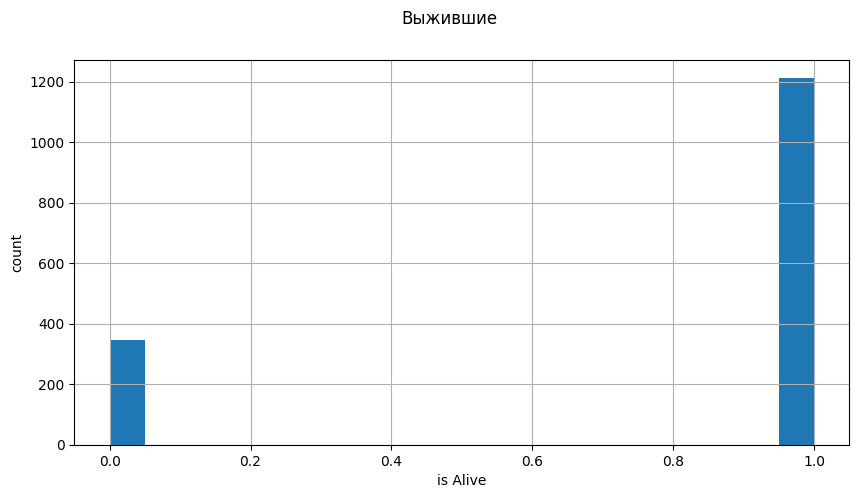

In [ ]:
plt.figure(figsize = (10, 5))

data_train['isAlive'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('is Alive')

plt.suptitle('Выжившие')
plt.show()

Ну... сомнительно, но окэй

**Задание 1.7.** Анализируем признаки.
  * Обработаем категориальные признаки и переведем их в числа.
  * Проанализируем количественные признаки.

Посмотрим на список признаков:

In [ ]:
data_train.columns

Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isAlive', 'isPopular', 'boolDeadRelations', 'cult', 'home',
       'tit', 'years'],
      dtype='object')

И заметим, что они сплошь категориальные. Занесем их список в отдельную переменную.

In [ ]:
feature_columns = ['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isPopular', 'boolDeadRelations', 'cult', 'home',
       'tit', 'years']
categorical_features = data_train[feature_columns]


И возьмем те, что еще не переведены в числа.

In [ ]:
unprocessed_cat_features = categorical_features.select_dtypes(include=[object]).columns.tolist()
unprocessed_cat_features

['cult', 'home', 'tit']

Выбор пал на OneHotEncoder. Ибо не хочется связываться с неучтенными отношениями порядка.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(data_train[unprocessed_cat_features])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_data = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=data_train.index
                          )

In [ ]:
# Concatenate the one-hot encoded dataframe with the original dataframe
data_encoded = pd.concat([data_train, one_hot_data], axis=1)

# Drop the original categorical columns
data_encoded = data_encoded.drop(unprocessed_cat_features, axis=1)

# Display the resulting dataframe
data_encoded

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,...,tit_Prince,tit_Princess,tit_Queen,tit_Septa,tit_Septon,tit_Ser,tit_Winterfell,tit_Wisdom,tit_other_tit,tit_unknown_tit
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1,1,1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,1,0,0,1,1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,1,1,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,0,0,0,1,0,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1554,0,1,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1555,1,0,1,1,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# perform one-hot encoding on the 'color' column
tit = pd.get_dummies(data_train['tit'])
cult = pd.get_dummies(data_train['cult'])
home = pd.get_dummies(data_train['home'])
# concatenate the one-hot encoding with the original dataframe
data_one_hot = pd.concat([data_train, tit, cult, home], axis=1)

# drop the original 'color' column
data_one_hot = data_one_hot.drop(['tit', 'cult', 'home'], axis=1)

И теперь у нас есть полностью оцифрованные признаки.

In [ ]:
data_one_hot

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,...,Osgrey,Second Sons,Stark,Stone Crows,Targaryen,Tully,Tyrell,Watch,other_home,unknown_home
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,1,...,False,False,False,False,True,False,False,False,False,False
2,1,1,1,1,1,1,1,1,1,1,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,1,0,0,1,1,0,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,0,0,1,1,0,0,...,False,False,False,False,False,False,False,False,False,False
5,0,0,0,0,1,0,1,1,1,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,1,0,...,False,False,False,False,False,False,False,False,False,True
1554,0,1,1,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
1555,1,0,1,1,1,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


Сделаем все то же самое с data_test, но с сохранением числа колонок:

In [ ]:
#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(data_train[unprocessed_cat_features])

one_hot_data = pd.DataFrame(
    one_hot_encoded[:len(data_test.index)],  # Ограничиваем до нужного количества строк
    columns=encoder.get_feature_names_out(unprocessed_cat_features),
    index=data_test.index
)

In [ ]:
# Concatenate the one-hot encoded dataframe with the original dataframe
data_encoded = pd.concat([data_test, one_hot_data], axis=1)

# Drop the original categorical columns
data_encoded = data_encoded.drop(unprocessed_cat_features, axis=1)

In [ ]:
# One-hot encoding для test
tit = pd.get_dummies(data_test['tit'])
cult = pd.get_dummies(data_test['cult'])
home = pd.get_dummies(data_test['home'])

# Объединяем с оригинальными данными
data_one_hot_test = pd.concat([data_test, tit, cult, home], axis=1)

# Удаляем исходные категориальные колонки
data_one_hot_test = data_one_hot_test.drop(['tit', 'cult', 'home'], axis=1)

# Гарантируем, что test имеет те же one-hot колонки, что и train
missing_cols = set(data_one_hot.columns) - set(data_one_hot_test.columns)

# Добавляем отсутствующие колонки с нулями
for col in missing_cols:
    data_one_hot_test[col] = 0

# Убедимся, что порядок колонок совпадает
data_one_hot_test = data_one_hot_test.reindex(columns=data_one_hot.columns, fill_value=0)
data_one_hot_test.drop(columns=['isAlive'], inplace=True)

Готово! Убедимся, что колонок на одну меньше, чем в data_one_hot:

In [ ]:
data_one_hot_test

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isPopular,boolDeadRelations,...,Osgrey,Second Sons,Stark,Stone Crows,Targaryen,Tully,Tyrell,Watch,other_home,unknown_home
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0,0,...,0,0,False,0,False,0,0,False,True,False
1559,0,0,1,1,1,1,0,0,1,0,...,0,0,False,0,False,0,0,False,True,False
1560,0,0,0,1,1,0,0,0,0,0,...,0,0,False,0,False,0,0,False,False,False
1561,1,1,1,1,1,1,0,1,0,0,...,0,0,False,0,False,0,0,False,True,False
1562,1,1,1,1,1,1,1,0,0,0,...,0,0,False,0,False,0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,1,1,1,1,1,1,0,0,0,0,...,0,0,True,0,False,0,0,False,False,False
1943,1,0,1,0,1,1,0,0,0,0,...,0,0,False,0,False,0,0,False,False,False
1944,1,1,1,1,1,1,0,0,0,0,...,0,0,False,0,False,0,0,False,False,True


Ура! Можно приступать к анализу:

**Задание 1.8.** Проанализируем влияние признаков на целевую переменную.

Посмотрим на связь титулов и выживаемости:

In [ ]:
pd.crosstab(data_train['tit'], data_one_hot['isAlive'])

isAlive,0,1
tit,,
Archmaester,0,21
Cupbearer,0,8
Khal,2,7
King,3,22
Lady,4,10
Lord,20,47
Maester,6,29
Master,5,3
Prince,10,4


Хорошо быть Архимейстером. Они удивительно живучи.

Глянем на корреляцию бинарных признаков с целевой переменной:

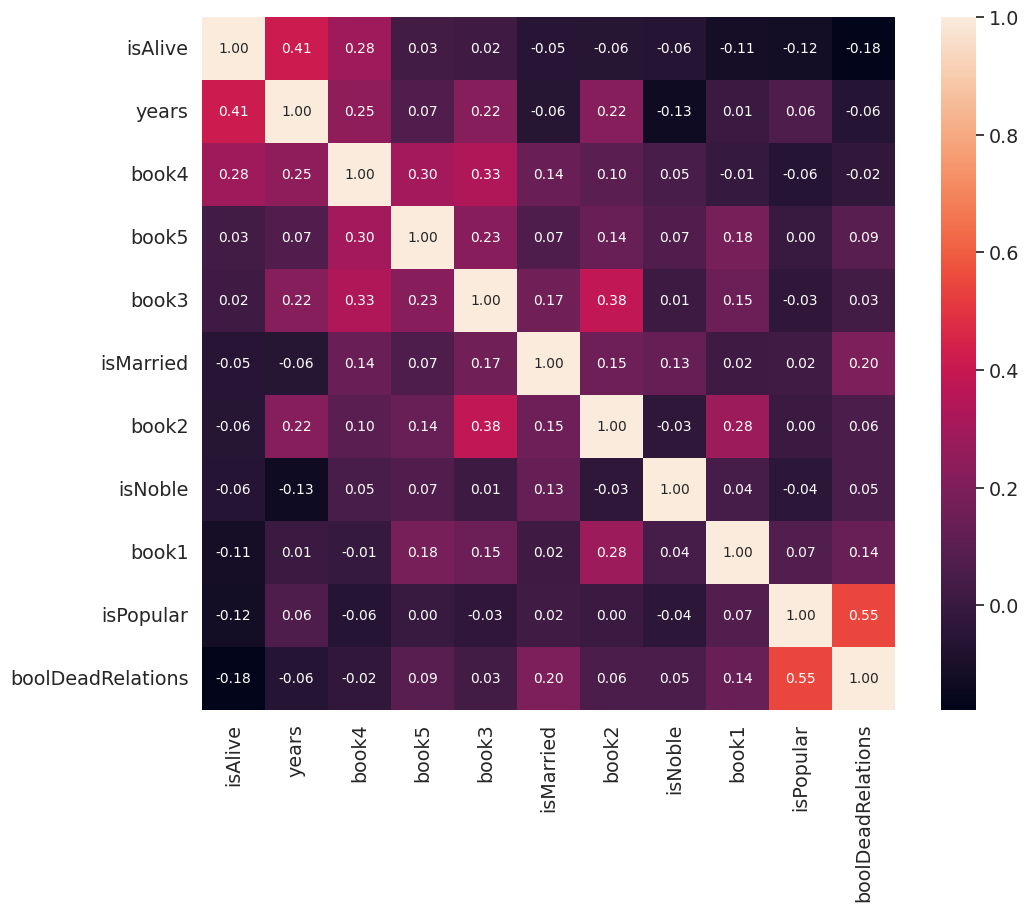

In [ ]:
import numpy as np
df = data_one_hot[['book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'isAlive', 'isPopular', 'years', 'boolDeadRelations']]
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))

# correlation matrix
k = 11 # number of variables for heatmap
cols = corrmat.nlargest(k, 'isAlive')['isAlive'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

Самая выраженная корреляция у популярности и количества мертвых друзей. А целевая переменная хорошо коррелирует с годами (не было б NaNoв, было бы 1).

Посмотрим на дома:

In [ ]:
data_train[['home', 'isAlive']].groupby(['home'], as_index=False).mean()

,home,isAlive
0,Alchemists' Guild,1.000000
1,Arryn,0.636364
2,Baratheon,0.941176
3,Faith of the Seven,0.857143
4,Frey,0.894737
5,Greyjoy,0.612903
6,Hightower,0.750000
7,House Ashford,1.000000
8,House Baelish,1.000000
9,House Beesbury,0.666667


И на культуры:

In [ ]:
data_train[['cult', 'isAlive']].groupby(['cult'], as_index=False).mean()

,cult,isAlive
0,Braavosi,0.975000
1,Dornish,0.952381
2,Free Folk,0.714286
3,Ghiscari,0.888889
4,Northmen,0.776699
5,Qartheen,0.833333
6,Reach,0.769231
7,Summer Islands,1.000000
8,Westermen,0.500000
9,dothraki,0.705882


Ну и можно еще диаграммы выживаемости полов посмотреть:

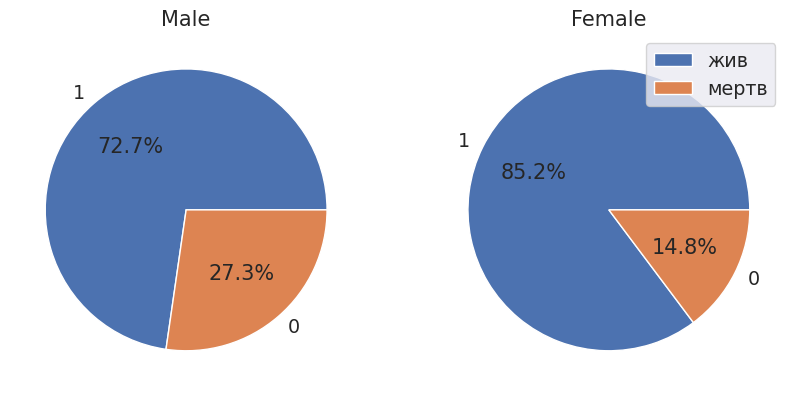

In [ ]:
# Готовим данные для графика
data1 = data_one_hot[data_one_hot['male'] == 1]['isAlive'].value_counts()
data2 = data_one_hot[data_one_hot['male'] == 0]['isAlive'].value_counts()
# Строим круговую диаграмму
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,8))

ax1.pie(data1.values, labels=data1.index, autopct='%1.1f%%')
ax2.pie(data2.values, labels=data2.index, autopct='%1.1f%%')

ax1.set_title("Male")
ax2.set_title("Female")

plt.legend(['жив', 'мертв'])

plt.show()

Популярность:

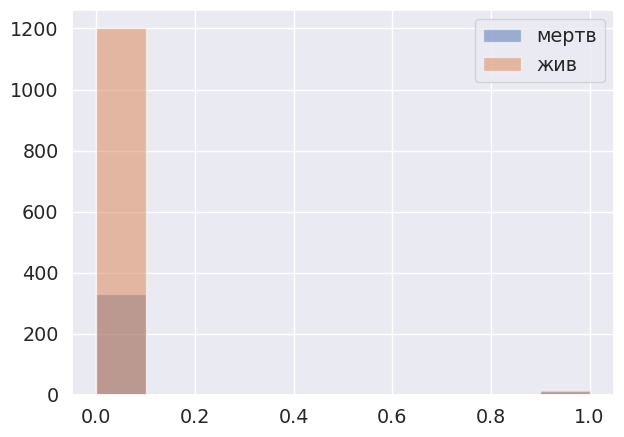

In [ ]:
plt.figure(figsize=(7, 5))

plt.hist(data_train['isPopular'][data_train['isAlive'] == 0], alpha=0.5, label='мертв')
plt.hist(data_train['isPopular'][data_train['isAlive'] == 1], alpha=0.5, label='жив')

plt.legend()

plt.show()

Ну и года :)

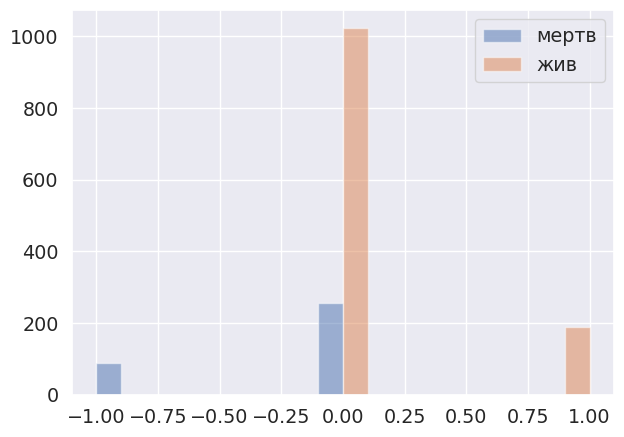

In [ ]:
plt.figure(figsize=(7, 5))

plt.hist(data_train['years'][data_train['isAlive'] == 0], alpha=0.5, label='мертв')
plt.hist(data_train['years'][data_train['isAlive'] == 1], alpha=0.5, label='жив')

plt.legend()

plt.show()

Kekekekekeke)

Тут можно было бы еще поиграться с боксплотами и с масштабированием, но и без них результат оказался весьма неплохим. Идем обучать!

**Задание 1.9.** Создадим переменную `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

X берем отсюда:

In [ ]:
data_one_hot.head()

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isAlive,isPopular,...,Osgrey,Second Sons,Stark,Stone Crows,Targaryen,Tully,Tyrell,Watch,other_home,unknown_home
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,1,...,False,False,False,False,True,False,False,False,False,False
2,1,1,1,1,1,1,1,1,1,1,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,1,0,0,1,1,0,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,0,0,1,1,0,0,...,False,False,False,False,False,False,False,False,False,False
5,0,0,0,0,1,0,1,1,1,0,...,False,False,False,False,False,False,False,False,True,False


X_test берем отсюда:

In [ ]:
data_one_hot_test.head()

,male,book1,book2,book3,book4,book5,isMarried,isNoble,isPopular,boolDeadRelations,...,Osgrey,Second Sons,Stark,Stone Crows,Targaryen,Tully,Tyrell,Watch,other_home,unknown_home
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0,0,...,0,0,False,0,False,0,0,False,True,False
1559,0,0,1,1,1,1,0,0,1,0,...,0,0,False,0,False,0,0,False,True,False
1560,0,0,0,1,1,0,0,0,0,0,...,0,0,False,0,False,0,0,False,False,False
1561,1,1,1,1,1,1,0,1,0,0,...,0,0,False,0,False,0,0,False,True,False
1562,1,1,1,1,1,1,1,0,0,0,...,0,0,False,0,False,0,0,False,False,False


Создадим переменную, в которой будет находиться список колонок, который мы по итогу передадим моделям:

In [ ]:
col = ['book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'isPopular', 'years', 'boolDeadRelations']

In [ ]:
X = data_one_hot[col].values
y = data_one_hot['isAlive'].values
#X_test = data_one_hot_test.values
X_test = data_one_hot_test[col].values
data_test['isAlive'] = 1 #чтобы посмотреть, сколько выживших насчитает итоговая модель
y_test = data_test['isAlive']

**Задание 1.10.** Разделим датасет на train и valid часть при помощи функции `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle=True)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируем следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируем остальные модели из библиотеки `sklearn`.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучим модель и сделаем предсказание на валидационной выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

Аналогичным образом обучим остальные модели и сделаем предсказания на тестовой выборке.

Шаг 1. Создание модели

In [ ]:
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),  n_estimators=200,  learning_rate=0.5)

In [ ]:
random_forest = RandomForestClassifier(n_estimators=200,  max_depth=10,  max_features="sqrt",  min_samples_split=5, random_state=42)

In [ ]:
gaussian_process = GaussianProcessClassifier(max_iter_predict=100)

In [ ]:
gaussian_nb = GaussianNB(var_smoothing=1e-9)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=13,  weights="distance",  metric="minkowski",  p=2)

In [ ]:
svc = SVC(kernel='rbf', C=10, gamma='scale')

In [ ]:
dtc = DecisionTreeClassifier(max_depth=7, min_samples_split=10, min_samples_leaf=5, criterion="entropy")

Шаг 2. Обучение модели

In [ ]:
adaboost.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
gaussian_process.fit(X_train, y_train)
gaussian_nb.fit(X_train, y_train)
knn.fit(X_train, y_train)
svc.fit(X_train, y_train)
dtc.fit(X_train, y_train)

Шаг 3. Предсказание на валидационных данных

In [ ]:
adaboost_pred = adaboost.predict(X_valid)
random_forest_pred = random_forest.predict(X_valid)
gaussian_process_pred = gaussian_process.predict(X_valid)
gaussian_nb_pred = gaussian_nb.predict(X_valid)
knn_pred = knn.predict(X_valid)
svc_pred = svc.predict(X_valid)
dtc_pred = dtc.predict(X_valid)

## Часть 3. Оцените качество моделей

Будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Посчитаем метрику для всех моделей и выберем лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_valid)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_valid, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8782


Аналогичным образом посчитаем метрику accuracy для остальных моделей

In [ ]:
# Предсказание на тестовых данных
y_pred_adaboost = adaboost.predict(X_valid)
y_pred_random_forest = random_forest.predict(X_valid)
y_pred_gaussian_process = gaussian_process.predict(X_valid)
y_pred_gaussian_nb = gaussian_nb.predict(X_valid)
y_pred_knn = knn.predict(X_valid)
y_pred_svc = svc.predict(X_valid)
y_pred_dtc = dtc.predict(X_valid)

In [ ]:
# Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_valid, y_pred_adaboost)
print("AdaBoost Accuracy : %.4f" % accuracy)
accuracy = accuracy_score(y_valid, y_pred_random_forest)
print("Random Forrest Accuracy : %.4f" % accuracy)
accuracy = accuracy_score(y_valid, y_pred_gaussian_process)
print("GaussianProcess Accuracy : %.4f" % accuracy)
accuracy = accuracy_score(y_valid, y_pred_gaussian_nb)
print("GaussianNBAccuracy : %.4f" % accuracy)
accuracy = accuracy_score(y_valid, y_pred_knn)
print("KnnAccuracy : %.4f" % accuracy)
accuracy = accuracy_score(y_valid, y_pred_svc)
print("SvcAccuracy : %.4f" % accuracy)
accuracy = accuracy_score(y_valid, y_pred_dtc)
print("DtcAccuracy : %.4f" % accuracy)

AdaBoost Accuracy : 0.8846
Random Forrest Accuracy : 0.8814
GaussianProcess Accuracy : 0.8750
GaussianNBAccuracy : 0.8654
KnnAccuracy : 0.8718
SvcAccuracy : 0.8878
DtcAccuracy : 0.8718


Лучше всех показала себя Svc. Ее и возьмем.

Еще раз проверим:

In [ ]:
svc = SVC(kernel='rbf', C=10, gamma='scale')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8878


Ну и наконец сделаем предсказание для X_test:

In [ ]:
y_pred = svc.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7455


### Файл `submission.csv`

Вместо значений в `submission.csv` файле в колонке `isAlive`, подставим свои предсказания и сохраним измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.1MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission = y_pred

Сохраним наш csv файл:

In [ ]:
import pandas as pd

# Преобразуем в DataFrame перед сохранением
submission_df = pd.DataFrame(submission, columns=["isAlive"])
submission_df.to_csv("new_submission_final.csv", index=False)

print("Файл new_submission_final.csv сохранён!")

Файл new_submission_final.csv сохранён!


И скачаем:

In [ ]:
from google.colab import files
files.download("new_submission_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Результат на Stepik вот такой :)

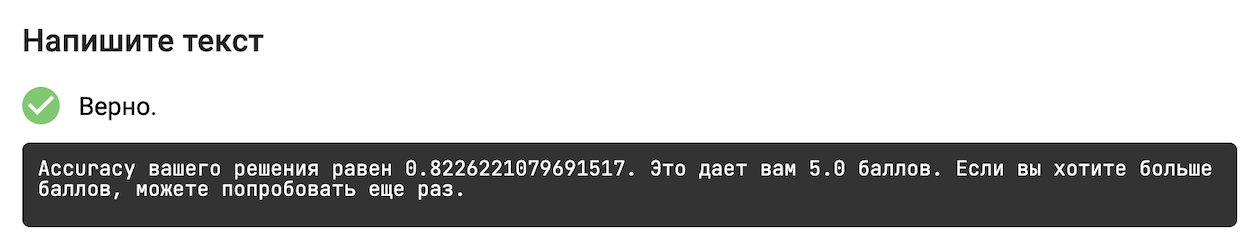

Огромное спасибо за то, что дочитали 🙏 \
Любым советам и рекомендациям буду очень рада! 💙